In [2]:
!pip --version

pip 24.0 from /opt/anaconda3/lib/python3.12/site-packages/pip (python 3.12)


# Preprocessing, Feature Engineering & Modellierung

**Einleitung:**

Basierend auf den Erkenntnissen der explorativen Datenanalyse (EDA) wird in diesem Notebook die Modellierung umgesetzt. Da die Verteilung der stetigen proxy_returnrate im ersten Schritt eine extrem unregelmäßige Struktur (zero-inflated) aufwies, fokussieren wir uns hier auf den Klassifikationsansatz mittels der binären Zielvariable num_returned.

Nachdem die Features über eine integrierte Pipeline (ColumnTransformer) durch Skalierung und OneHotEncoder aufbereitet wurden, trainieren wir vier Algorithmen: eine Logistische Regression, einen Entscheidungsbaum, XGBoost sowie ein K-Nearest-Neighbors-Modell. Die finale Evaluation erfolgt praxisnah über die Confusion Matrix, um die "Accuracy-Falle" des unausgeglichenen Datensatzes zu umgehen. Darauf aufbauend aggregieren wir die Vorhersagen, um eine Top 10 Risiko-Produktliste für das operative Shop-Management abzuleiten und unsere zentrale Forschungsfrage zu beantworten.

**Forschungsfrage:**

`Unterscheiden sich Retourenraten signifikant zwischen Produktkategorien?`

## Import Packages

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_qqplot import pplot
import numpy as np
from ydata_profiling import ProfileReport
import random

In [10]:
from scipy import stats
import math
import scipy.stats as stats
import statsmodels.formula.api as smf
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

In [214]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    Normalizer,
    QuantileTransformer,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures,
    FunctionTransformer,
    PowerTransformer
)
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

In [150]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)


from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

## File Directories

In [52]:
INPUT_DIR = os.path.join("../input")

In [54]:
OUTPUT_DIR = os.path.join("../output")

In [56]:
DOC_DIR = os.path.join("../documents")

In [58]:
FILE_DIR = os.path.join("../input")

## Load Data

In [61]:
df_superstore = pd.read_csv(os.path.join(OUTPUT_DIR,"merged_superstore_df.csv"))

In [63]:
df_superstore.dtypes

Unnamed: 0                    int64
Row ID                        int64
Order ID                     object
Order Date                   object
Ship Date                    object
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
City                         object
State                        object
Country                      object
Postal Code                 float64
Market                       object
Region                       object
product_id                   object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Shipping Cost               float64
Order Priority               object
Returned                     object
num_returned                  int64
order_to_ship_date          

## Prepare

In [66]:
df_superstore = df_superstore.rename(
    columns={
        "shipping-cost": "shipping_cost",
        "Order Date": "order_date",
        "Postal Code": "postal_code",
        "Sub-Category": "sub_category",
        "Product Name": "product_name",
        "Shipping Cost":"shipping_cost",
        "Order Priority": "order_priority",
        "Ship Date": "ship_date",
        "Ship Mode": "ship_mode",
        "Customer Name": "customer_name",
        "Customer ID": "customer_id",
        "Row ID": "row_id",
        "Order ID": "order_id",
        "Product ID": "product_id",
    }
)

In [68]:
df_superstore.columns

Index(['Unnamed: 0', 'row_id', 'order_id', 'order_date', 'ship_date',
       'ship_mode', 'customer_id', 'customer_name', 'Segment', 'City', 'State',
       'Country', 'postal_code', 'Market', 'Region', 'product_id', 'Category',
       'sub_category', 'product_name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'shipping_cost', 'order_priority', 'Returned', 'num_returned',
       'order_to_ship_date', 'num_orders', 'num_orders_returned',
       'proxy_returnrate', 'unique_products_in_order', 'order_product_share',
       'order_month', 'cat_discount', 'customer_return'],
      dtype='object')

### Variable Lists

In [71]:
target_col = ["num_returned"]

In [73]:
cat_features_col = ["Market", "Segment", "Region", "sub_category" ,'City', 'State','Country', "cat_discount"]

In [75]:
num_features_col = [ "Sales","Profit", "order_to_ship_date", "shipping_cost", "order_product_share", "customer_return", "order_month"]

### Aufteilung des Datensatzes

In [79]:
train_df, test_df = train_test_split(df_superstore, random_state=42)

## Pipelines

### ColumnTransformer

In [83]:
col_transform_pipeline = ColumnTransformer(
    [
        ("std_scaler", StandardScaler(),["shipping_cost", "Sales", "Profit"]),
        ("onehot_transformer", OneHotEncoder(), ["Market", "Segment", "sub_category"]),
        ("ordinal_transformer", OrdinalEncoder(), ["cat_discount", "order_to_ship_date", "order_product_share", "order_month", "customer_return"]),
        
        
    ]
)

## Prepare Training-Set

In [85]:
def prepare_for_pipeline(df):
    print("Original shape:", df.shape)
    df = df[cat_features_col + num_features_col + ["num_returned"]].dropna()
    print("Shape after dropna():", df.shape)
    x = df[cat_features_col + num_features_col]
    y = df[["num_returned"]]
    print("Shape after feature selection:", x.shape)
    return x, y

### Transform Features

In [87]:
x_train, y_train = prepare_for_pipeline(train_df)

Original shape: (38471, 36)
Shape after dropna(): (38471, 16)
Shape after feature selection: (38471, 15)


In [89]:
x_train_transformed = col_transform_pipeline.fit_transform(x_train)

**Array-Output von der Pipeline in DataFrame konvertieren**

In [92]:
def array_to_df(list_array, col_names):
    
    new_df = pd.DataFrame(list_array, columns=col_names)
    new_df = new_df.reset_index(drop=True)
    
    return new_df

In [94]:
x_col_names = col_transform_pipeline.get_feature_names_out()

In [96]:
x_train_transformed_df = array_to_df(x_train_transformed, x_col_names)

## Prepare Test-Set

### Transform Features

In [98]:
x_test, y_test = prepare_for_pipeline(test_df)

Original shape: (12824, 36)
Shape after dropna(): (12824, 16)
Shape after feature selection: (12824, 15)


In [100]:
x_test_transformed = col_transform_pipeline.transform(x_test)

In [102]:
x_test_col_names = col_transform_pipeline.get_feature_names_out()

In [104]:
x_test_transformed_df = array_to_df(x_test_transformed, x_test_col_names)

## Analysis

**NOTE:**

---
In diesem Abschnitt trainieren und evaluieren wir die ausgewählten Klassifikationsmodelle. Um die bestmögliche Performance zu erzielen, setzen wir für jeden Algorithmus jeweils zwei Versionen auf:

Baseline-Modell: Das Modell in der Standardkonfiguration mit Standard-Hyperparametern.

Optimiertes Modell: Das Modell nach der Hyperparameter-Optimierung (mittels GridSearch bzw. RandomizedSearch).

Die jeweils zweiten, optimierten Modellversionen werden anschließend einer 10-fachen Crossvalidation unterzogen.

---

### Logistic Regression

#### Erstes Model aufsetzen

In [140]:
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

In [106]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg_m1 = logreg.fit(x_train_transformed_df, y_train)
logreg_m1.score(x_train_transformed_df, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.7244157937147462

#### Hyperparametern-Optimierung

**solver**

In [110]:
solver_list = ["newton-cg", "lbfgs", "liblinear", "sag", "saga", 'newton-cholesky']

model_score_list = []

for s in solver_list:
    solver_value = s
    logreg = LogisticRegression(max_iter=1000, solver=solver_value, class_weight="balanced")
    logreg_m1 = logreg.fit(x_train_transformed_df, y_train)
    score = logreg_m1.score(x_train_transformed_df, y_train)
    model_score_list.append(score)

print(model_score_list)
    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

[0.7245977489537574, 0.7244157937147462, 0.7246497361649035, 0.7246757297704765, 0.7247537105871955, 0.7245717553481843]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**max_iter**

In [112]:
list_max_iter = []

for m in range(0, 1000, 100):
    max_iter_value = m
    logreg = LogisticRegression(max_iter=max_iter_value, class_weight="balanced")
    logreg_m1 = logreg.fit(x_train_transformed_df, y_train)
    score = logreg_m1.score(x_train_transformed_df, y_train)

    list_max_iter.append(score)

print(list_max_iter)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=0).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array wa

[0.5302175664786463, 0.7247797041927686, 0.7244677809258923, 0.7244417873203192, 0.7244157937147462, 0.7244157937147462, 0.7244157937147462, 0.7244157937147462, 0.7244157937147462, 0.7244157937147462]


**penalty(c)**

In [114]:
list_c_scores = []

c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for c in c_values:
    logreg = LogisticRegression(
        C=c, solver="newton-cg", max_iter=200, class_weight="balanced"
    )
    logreg_m1 = logreg.fit(x_train_transformed_df, y_train)
    c_score = logreg_m1.score(x_train_transformed_df, y_train)
    list_c_scores.append((c, c_score))

print(list_c_scores)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

[(0.001, 0.7446128252449897), (0.01, 0.7339034597489018), (0.1, 0.7266772373995997), (1.0, 0.7245977489537574), (10.0, 0.724311819292454), (100.0, 0.724259832081308)]


#### Zweites Model aufsetzen

In [265]:
logreg = LogisticRegression(max_iter=200, solver= "newton-cg", C=0.001, class_weight="balanced")
logreg_m2 = logreg.fit(x_train_transformed_df, y_train)
logreg_m2_score= logreg_m2.score(x_train_transformed_df, y_train)

#### Crossvalidation

In [118]:
logreg_c_scores = cross_val_score(
    logreg_m2, 
    x_train_transformed_df, 
    y_train, 
    scoring="f1_weighted", 
    cv=10
)

print("CV-Scores pro Fold (F1-Weighted):", logreg_c_scores)
print(f"Durchschnittlicher CV-Score (F1-Weighted): {logreg_c_scores.mean():.3f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

CV-Scores pro Fold (F1-Weighted): [0.81799517 0.8092673  0.80806158 0.81755277 0.80445369 0.81226363
 0.81164673 0.80742147 0.81559404 0.7963637 ]
Durchschnittlicher CV-Score (F1-Weighted): 0.810


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Entscheidungsbäume

#### Erstes Model aufsetzen

In [120]:
dt_clf = DecisionTreeClassifier(max_depth=3, class_weight="balanced")
dt_clf_m1 = dt_clf.fit(x_train_transformed_df, y_train)
dt_clf_m1_score = dt_clf_m1.score(x_train_transformed_df, y_train)
dt_clf_m1_score

0.5222895167788724

In [323]:
dt_clf_m1.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

#### Hyperparametern-Optimierung

In [122]:
dtclass_parameter = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3, 5, 10, 15, 20, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [2, 10, 30, 50],
    "min_impurity_decrease": [0.0, 0.01],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

In [124]:
grid_search = GridSearchCV(
    estimator=dt_clf_m1,
    param_grid=dtclass_parameter,
    cv=10,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

In [126]:
grid_search.fit(x_train_transformed_df, y_train)

best_dt_model = grid_search.best_estimator_
print(f"Beste Parameter: {grid_search.best_params_}")

Fitting 10 folds for each of 1728 candidates, totalling 17280 fits
Beste Parameter: {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'splitter': 'random'}


#### Zweites Model aufsetzen

In [278]:
dt_clf2 = DecisionTreeClassifier(criterion="entropy" ,splitter="random", min_samples_leaf=2)
dt_clf_m2 = dt_clf2.fit(x_train_transformed_df, y_train)
dt_clf_m2_score = dt_clf_m2.score(x_train_transformed_df, y_train)

In [282]:
dt_clf_m2_score

0.9782173585298016

#### Crossvalidation

In [130]:
dtclass_c_scores2 =  cross_val_score(
    dt_clf_m2, 
    x_train_transformed_df, 
    y_train, 
    scoring="f1_weighted", 
    cv=10
)


print("CV-Scores pro Fold (F1-Weighted):", dtclass_c_scores2)
print(f"Durchschnittlicher CV-Score (F1-Weighted): {dtclass_c_scores2.mean():.3f}")

CV-Scores pro Fold (F1-Weighted): [0.93513748 0.92650936 0.93454789 0.93241932 0.93410465 0.93036463
 0.93046654 0.93524484 0.93718699 0.93171947]
Durchschnittlicher CV-Score (F1-Weighted): 0.933


### KNN

#### Erste Model aufsetzen

In [132]:
neigh = KNeighborsClassifier(n_neighbors=5)
neigh_m1 = neigh.fit(x_train_transformed_df, y_train)

neigh_m1_score = neigh_m1.score(x_train_transformed_df, y_train)
neigh_m1_score

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9607756491902992

#### Hyperparameter-Optimierung

In [134]:
knn_parameter = {
    "n_neighbors": [3, 5, 11, 19, 25],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
    "algorithm": ["auto", "brute"],
}

In [136]:
grid_search_neigh = GridSearchCV(
    estimator=neigh_m1,
    param_grid=knn_parameter,
    cv=10,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

In [142]:
grid_search_neigh.fit(x_train_transformed_df, y_train)

best_neigh_model = grid_search_neigh.best_estimator_
print(f"Beste Parameter: {grid_search_neigh.best_params_}")

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Beste Parameter: {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}


#### Zweites Model aufsetzen

In [292]:
neigh2 = KNeighborsClassifier(algorithm="auto",n_neighbors=3, p=1, weights ="distance")
neigh_m2 = neigh2.fit(x_train_transformed_df, y_train)

neigh_m2_score = neigh_m2.score(x_train_transformed_df, y_train)

#### Crossvalidation

In [146]:
neigh2_c_scores = cross_val_score(
    neigh_m2, 
    x_train_transformed_df, 
    y_train, 
    scoring="f1", 
    cv=10
)

print("CV-Scores pro Fold:", neigh2_c_scores)
print(f"Durchschnittlicher CV-Score (R²): {neigh2_c_scores.mean():.3f}")

CV-Scores pro Fold: [0.4690027  0.38857143 0.47593583 0.4516129  0.52519894 0.4076087
 0.50420168 0.44956772 0.50673854 0.41242938]
Durchschnittlicher CV-Score (R²): 0.459


### XGBOOST

#### Erstes Model aufsetzen

In [171]:
xgb_clf = xgb.XGBClassifier(random_state=42)
xgb_clf_m1 = xgb_clf.fit(x_train_transformed_df, y_train)

xgb_clf_m1.score(x_train_transformed_df, y_train)

0.9565646850874685

#### Hyperparameter-Optimierung

In [173]:
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

In [178]:
tscv = TimeSeriesSplit(n_splits=3)

In [180]:
random_search = RandomizedSearchCV(
    estimator=xgb_clf_m1,
    param_distributions=param_distributions,
    n_iter=10,           
    cv=tscv,             
    scoring='f1',
    n_jobs=1,
    random_state=42,
    verbose=1
)

In [184]:
random_search.fit(x_train_transformed, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...state=42, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### Zweites Model aufsetzen

In [269]:
xgb_clf2 = xgb.XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.2,
    max_depth=5,
    use_label_encoder=False,
    n_estimators=200,
    eval_metric='logloss',
    subsample=1.0
)

xgb_clf_m2 = xgb_clf2.fit(x_train_transformed_df, y_train)

xgb_clf_m2_score = xgb_clf_m2.score(x_train_transformed_df, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


## Preview

**NOTE:**

---

In diesem Abschnitt erfolgt die finale Validierung aller trainierten Modellversionen auf dem Testset.

Um die Leistung der Baseline-Modelle (Version 1) und der optimierten Modelle (Version 2) transparent zu vergleichen, nutzen wir zwei die `Accuracy` und `F1-Score` als Messwerte

---

### Logistische Regression

In [157]:
y_pred_logreg = logreg_m1.predict(x_test_transformed_df)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {logreg_accuracy:.4f}")
print(f"F1-Score (Weighted): {logreg_f1:.4f}")

Accuracy (Gesamtgenauigkeit): 0.7268
F1-Score (Weighted): 0.7992


In [161]:
y_pred_logreg = logreg_m2.predict(x_test_transformed_df)

logreg2_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg2_f1 = f1_score(y_test, y_pred_logreg, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {logreg2_accuracy:.4f}")
print(f"F1-Score (Weighted): {logreg2_f1:.4f}")

Accuracy (Gesamtgenauigkeit): 0.7476
F1-Score (Weighted): 0.8136


### Entscheidungsbäume

In [163]:
dt_clf1_m1_y_pred = dt_clf_m1.predict(x_test_transformed_df)


dt_clf1_accuracy = accuracy_score(y_test, dt_clf1_m1_y_pred)
dt_clf1_f1 = f1_score(y_test, dt_clf1_m1_y_pred, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {dt_clf1_accuracy:.4f}")
print(f"F1-Score (Weighted): {dt_clf1_f1:.4f}")

Accuracy (Gesamtgenauigkeit): 0.5200
F1-Score (Weighted): 0.6313


In [165]:
dt_clf1_m2_y_pred = dt_clf_m2.predict(x_test_transformed_df)


dt_clf2_accuracy = accuracy_score(y_test, dt_clf1_m2_y_pred)
dt_clf2_f1 = f1_score(y_test, dt_clf1_m2_y_pred, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {dt_clf2_accuracy:.4f}")
print(f"F1-Score (Weighted): {dt_clf2_f1:.4f}")

Accuracy (Gesamtgenauigkeit): 0.9397
F1-Score (Weighted): 0.9357


### XGBOOST

In [205]:
xgb_clf_y_pred = xgb_clf_m1.predict(x_test_transformed_df)

xgb_clf_accuracy_score = accuracy_score(y_test, xgb_clf_y_pred)
xgb_clf_f1_score = f1_score(y_test, xgb_clf_y_pred, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {xgb_clf_accuracy_score}")
print(f"F1-Score (Weighted): {xgb_clf_f1_score}")

Accuracy (Gesamtgenauigkeit): 0.9469744229569557
F1-Score (Weighted): 0.928449343477752


In [207]:
xgb2_clf_y_pred = xgb_clf_m2.predict(x_test_transformed_df)

xgb_clf2_accuracy_score = accuracy_score(y_test, xgb2_clf_y_pred)
xgb_clf2_f1_score = f1_score(y_test, xgb2_clf_y_pred, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {xgb_clf2_accuracy_score}")
print(f"F1-Score (Weighted): {xgb_clf2_f1_score}")

Accuracy (Gesamtgenauigkeit): 0.9470524017467249
F1-Score (Weighted): 0.9276540898826512


### KNN

In [167]:
neigh_y_pred = neigh_m1.predict(x_test_transformed_df)

neigh_accuracy_score = accuracy_score(y_test, neigh_y_pred)
neigh_f1_score = f1_score(y_test, neigh_y_pred, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {neigh_accuracy_score}")
print(f"F1-Score (Weighted): {neigh_f1_score}")

Accuracy (Gesamtgenauigkeit): 0.9518091079226451
F1-Score (Weighted): 0.941653378802555


In [169]:
neigh_y_pred2 = neigh_m2.predict(x_test_transformed_df)

neigh2_accuracy_score = accuracy_score(y_test, neigh_y_pred2)
neigh2_f1_score = f1_score(y_test, neigh_y_pred2, average="weighted")

print(f"Accuracy (Gesamtgenauigkeit): {neigh2_accuracy_score}")
print(f"F1-Score (Weighted): {neigh2_f1_score}")

Accuracy (Gesamtgenauigkeit): 0.950483468496569
F1-Score (Weighted): 0.9440903379530068


## Visualisation

In [296]:
training_accuracy = [logreg_m2_score, dt_clf_m2_score,xgb_clf_m2_score, neigh_m2_score]
training_accuracy

[0.7446128252449897, 0.9782173585298016, 0.953497439629851, 1.0]

In [308]:
test_accuracy = [logreg2_accuracy-logreg_m2_score, dt_clf2_accuracy-dt_clf_m2_score, xgb_clf2_accuracy_score-xgb_clf_m2_score, neigh2_accuracy_score-neigh_m2_score]

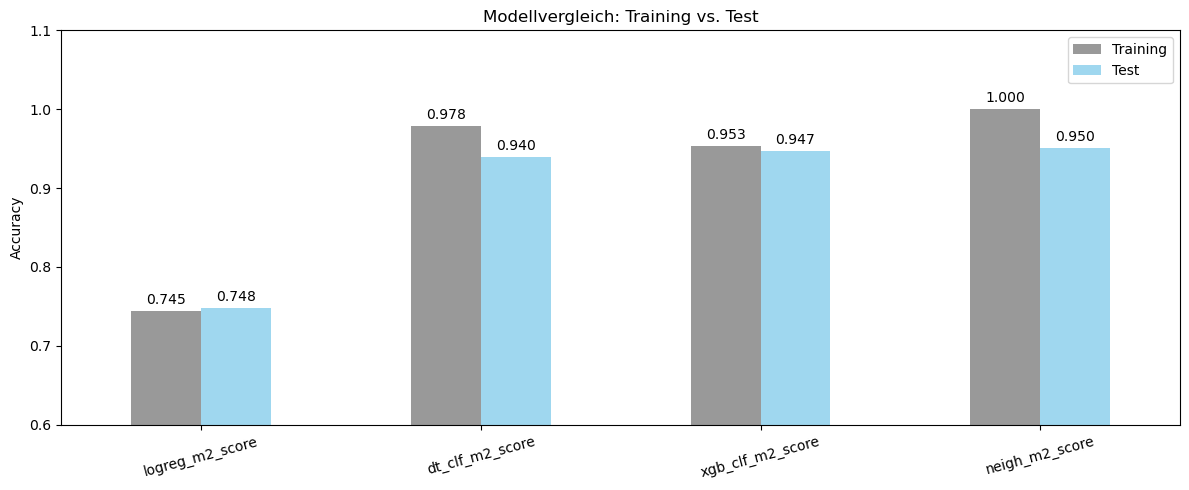

In [328]:
data = {
    'Training': [logreg_m2_score, dt_clf_m2_score, xgb_clf_m2_score, neigh_m2_score],
    'Test': [logreg2_accuracy, dt_clf2_accuracy, xgb_clf2_accuracy_score, neigh2_accuracy_score]
}
x_labels = ['logreg_m2_score', 'dt_clf_m2_score', 'xgb_clf_m2_score', 'neigh_m2_score']
df = pd.DataFrame(data, index=x_labels)

fig, ax = plt.subplots(figsize=(12, 5))
df.plot(kind='bar', color=['grey', 'skyblue'], alpha=0.8, rot=15, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.ylim(0.6, 1.1)

plt.ylabel('Accuracy')
plt.title('Modellvergleich: Training vs. Test')
plt.legend()
plt.tight_layout()
plt.show()

## Confusion Matrix

### Logistic Regression

In [216]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred_logreg)

In [244]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)

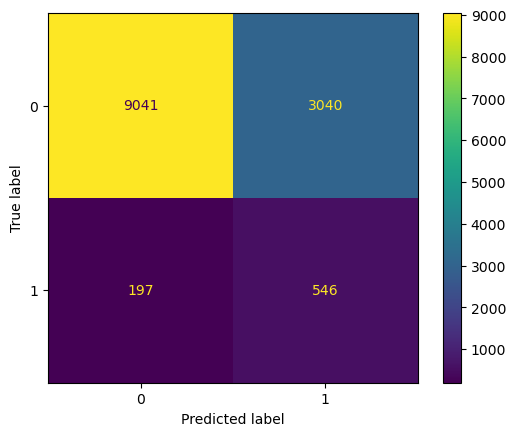

In [246]:
cm_display.plot()
plt.show()

In [372]:
logreg_recall = metrics.precision_score(y_test, y_pred_logreg)
logreg_precision = metrics.recall_score(y_test, y_pred_logreg)
print(f"Accuracy = {metrics.accuracy_score(y_test, y_pred_logreg)}")
print(f"Precision = {logreg_precision}")
print(f"Recall = {logreg_recall}")

Accuracy = 0.7475826575171554
Precision = 0.7348586810228802
Recall = 0.15225878416062466


### Entscheidungsbaum

In [233]:
dt_clf1_m2_confusion_matrix = metrics.confusion_matrix(y_test, dt_clf1_m2_y_pred)

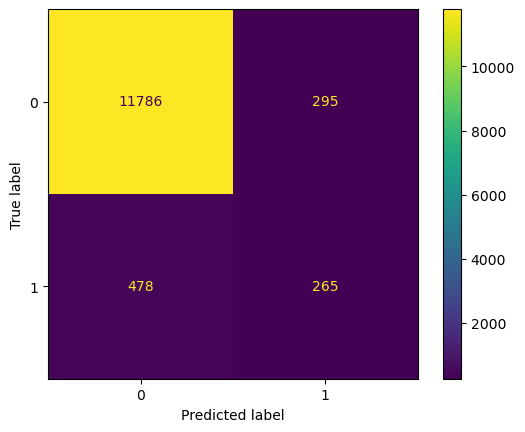

In [235]:
dt_clf1_m2_cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = dt_clf1_m2_confusion_matrix)
dt_clf1_m2_cm_display.plot()
plt.show()

In [356]:
dt_clf1_m2_precision = metrics.precision_score(y_test, dt_clf1_m2_y_pred)
dt_clf1_m2_recall = metrics.recall_score(y_test, dt_clf1_m2_y_pred)
print(f"Accuracy = {metrics.accuracy_score(y_test, dt_clf1_m2_y_pred)}")
print(f"Precision {dt_clf1_m2_precision}")
print(f"Recall {dt_clf1_m2_recall}")

Accuracy = 0.9397223955084217
Precision 0.4732142857142857
Recall 0.3566621803499327


### XGBOOST

In [335]:
xgb2_clf_confusion_matrix = metrics.confusion_matrix(y_test, xgb2_clf_y_pred)

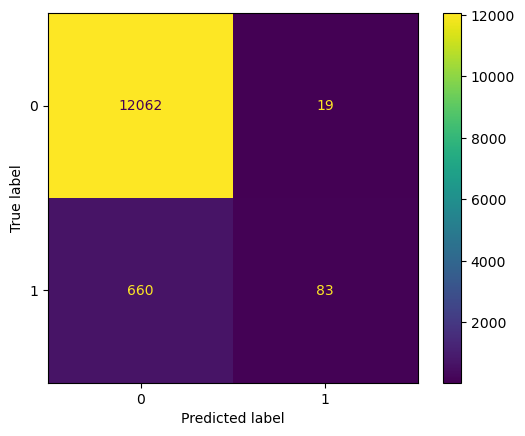

In [337]:
xgb2_clf_cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = xgb2_clf_confusion_matrix)
xgb2_clf_cm_display.plot()
plt.show()

In [358]:
xgb2_clf_precision = metrics.precision_score(y_test, xgb2_clf_y_pred)
xgb2_clf_recall = metrics.recall_score(y_test, xgb2_clf_y_pred)
print(f"Accuracy = {metrics.accuracy_score(y_test, xgb2_clf_y_pred)}")
print(f"Precision = {xgb2_clf_precision}")
print(f"Recall = {xgb2_clf_recall}")

Accuracy = 0.9470524017467249
Precision = 0.8137254901960784
Recall = 0.1117092866756393


### KNN

In [252]:
neigh_y_pred2_confusion_matrix = metrics.confusion_matrix(y_test, neigh_y_pred2)

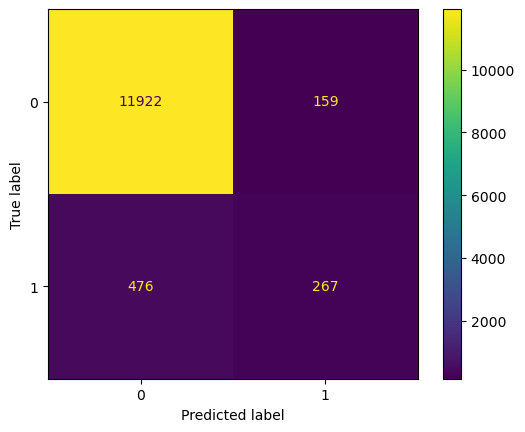

In [254]:
neigh_cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = neigh_y_pred2_confusion_matrix)
neigh_cm_display.plot()
plt.show()

In [366]:
neigh_precision = metrics.precision_score(y_test, neigh_y_pred2)
neigh_recall = metrics.recall_score(y_test, neigh_y_pred2)
print(f"Accuracy = {metrics.accuracy_score(y_test, neigh_y_pred2)}")
print(f"Precision = {neigh_precision}")
print(f"Recall = {neigh_recall}")

Accuracy = 0.950483468496569
Precision = 0.6267605633802817
Recall = 0.35935397039030953


## Final Visualisation

### Modellvergleich: Training vs. Test

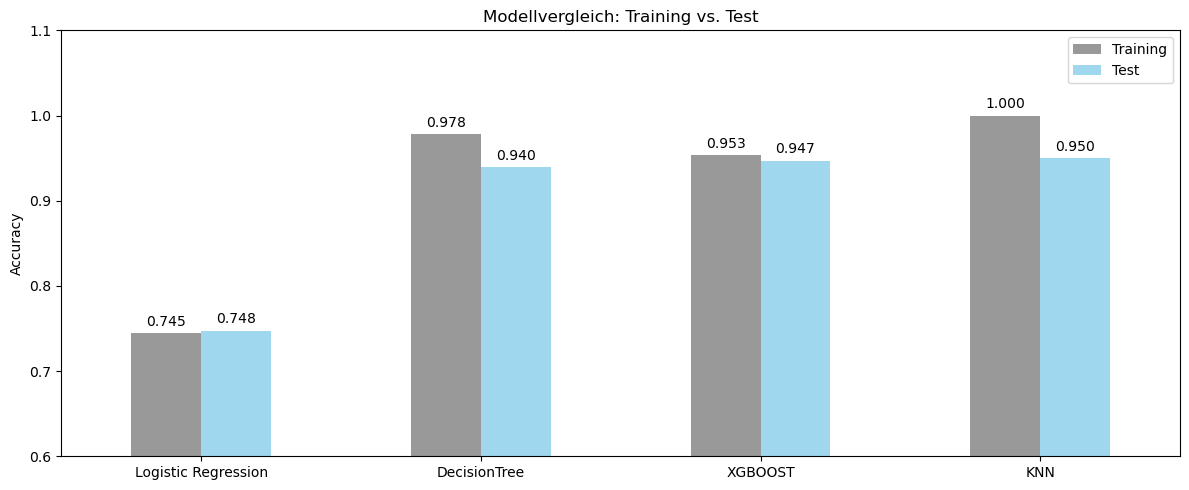

In [455]:
data = {
    'Training': [logreg_m2_score, dt_clf_m2_score, xgb_clf_m2_score, neigh_m2_score],
    'Test': [logreg2_accuracy, dt_clf2_accuracy, xgb_clf2_accuracy_score, neigh2_accuracy_score]
}
x_labels = ["Logistic Regression", "DecisionTree", "XGBOOST", "KNN"]
df = pd.DataFrame(data, index=x_labels)

fig, ax = plt.subplots(figsize=(12, 5))
df.plot(kind='bar', color=['grey', 'skyblue'], alpha=0.8, rot=0, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.ylim(0.6, 1.1)

plt.ylabel('Accuracy')
plt.title('Modellvergleich: Training vs. Test')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DOC_DIR,"modellvergleich.png"))
plt.show()

### Modellvergleich: Recall vs. Präzision

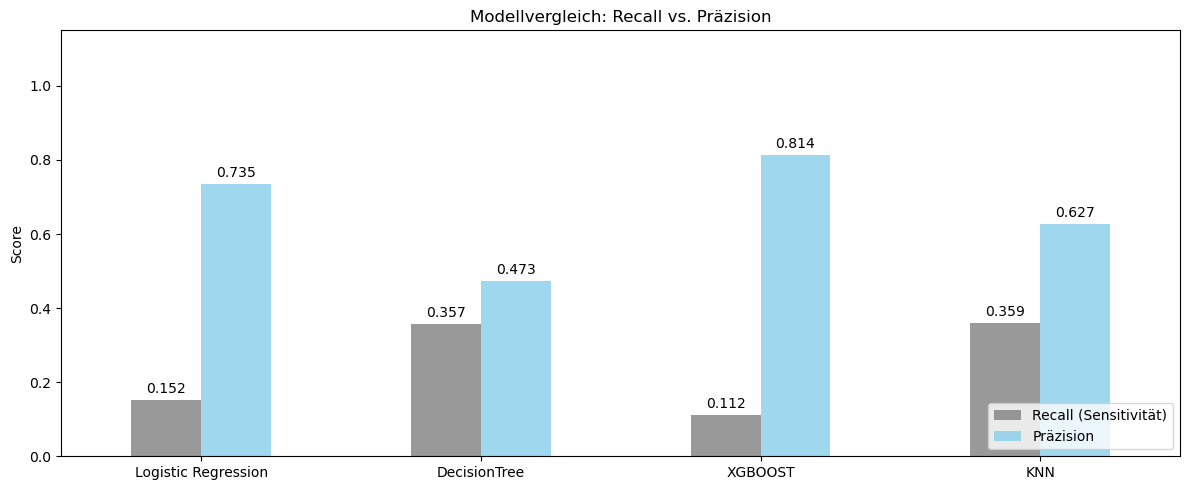

In [457]:
data = {
    'Recall (Sensitivität)': [logreg_recall, dt_clf1_m2_recall, xgb2_clf_recall, neigh_recall],
    'Präzision': [logreg_precision, dt_clf1_m2_precision, xgb2_clf_precision, neigh_precision]
}
x_labels = ["Logistic Regression", "DecisionTree", "XGBOOST", "KNN"]
df = pd.DataFrame(data, index=x_labels)

fig, ax = plt.subplots(figsize=(12, 5))
df.plot(kind='bar', color=['grey', 'skyblue'], alpha=0.8, rot=0, ax=ax)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.ylim(0, 1.15)
plt.ylabel("Score")
plt.title('Modellvergleich: Recall vs. Präzision')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DOC_DIR,"modellvergleich_recall_praezision.png"))
plt.show()

### Top 10 Produkte mit höchste Retourenwahrscheinlichkeit

In [404]:
y_prob_test = neigh_m1.predict_proba(x_train_transformed_df)[:, 1]

In [430]:
df_predictions = x_train_transformed_df.copy()

df_predictions["Product_ID"] = df_superstore.loc[x_train_transformed_df.index, "product_id"] 
df_predictions["Product_Name"] = df_superstore.loc[x_train_transformed_df.index, "product_name"]

df_predictions["Retouren_Wahrscheinlichkeit"] = y_prob_test

In [436]:
product_risk_df = df_predictions.groupby(["Product_ID", "Product_Name"])["Retouren_Wahrscheinlichkeit"].mean().reset_index()
product_risk_df = product_risk_df.sort_values(by="Retouren_Wahrscheinlichkeit", ascending=False)

In [438]:
top_10_risky = product_risk_df.head(10)
top_10_risky.columns = ["Produkt ID", "Produktname", "Retouren-Wahrscheinlichkeit"]
top_10_risky

,Produkt ID,Produktname,Retouren-Wahrscheinlichkeit
3382,OFF-BI-10000279,"Acco Recycled 2"" Capacity Laser Printer Hangin...",1.0
8173,TEC-CO-10000777,"Brother Personal Copier, Laser",1.0
4368,OFF-EN-10003073,"Jiffy Business Envelopes, Set of 50",1.0
661,FUR-CH-10001220,"Harbour Creations Chairmat, Set of Two",1.0
7425,OFF-WIL-10003774,"Wilson Jones Index Tab, Economy",1.0
5636,OFF-PA-10000300,Xerox 1936,1.0
1598,FUR-FU-10004020,Advantus Panel Wall Acrylic Frame,1.0
6337,OFF-ST-10000022,"Eldon Folders, Industrial",1.0
2076,FUR-TA-10002351,"Hon Training Table, Adjustable Height",1.0
1569,FUR-FU-10003826,"Eldon Door Stop, Duo Pack",1.0
